### Soil Texture Mapping: Integrating Google Earth Engine and Python for Precise Geospatial Analysis

### Imports

In [2]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

import geopandas as gpd
import pandas as pd
import numpy as np

import rioxarray as rxr

### Export Shape file

In [3]:
# Administrative level 0 (Country boundary)
adm0_url = "https://github.com/wmgeolab/geoBoundaries/raw/main/releaseData/gbOpen/FRA/ADM0/geoBoundaries-FRA-ADM0.geojson"
adm0 = gpd.read_file(adm0_url)

# Administrative level 1 (Regions)
adm1_url = "https://github.com/wmgeolab/geoBoundaries/raw/main/releaseData/gbOpen/FRA/ADM1/geoBoundaries-FRA-ADM1.geojson"
adm1 = gpd.read_file(adm1_url)

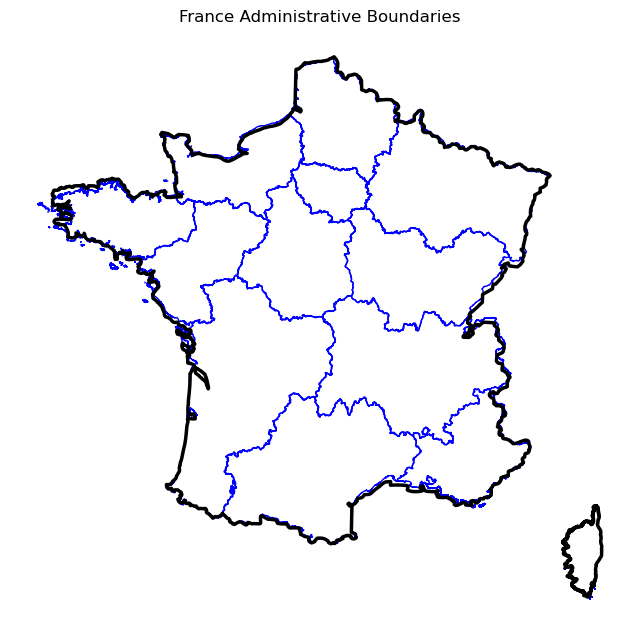

In [4]:
# Create figure
fig, ax = plt.subplots(figsize=(8, 10))

# Plot ADM1 boundaries
adm1.boundary.plot(
    ax=ax,
    edgecolor="blue",
    linewidth=1
)

# Plot country boundary
adm0.boundary.plot(
    ax=ax,
    edgecolor="black",
    linewidth=2.5
)

plt.title("France Administrative Boundaries")
plt.axis("off")
plt.show()

In [26]:
# Create the output folder if it doesn't exist
os.makedirs("data", exist_ok=True)

# Save as ESRI Shapefile
adm0.to_file(
    "data/France.shp",
    driver="ESRI Shapefile"
)

### Import from Google Earth Engine

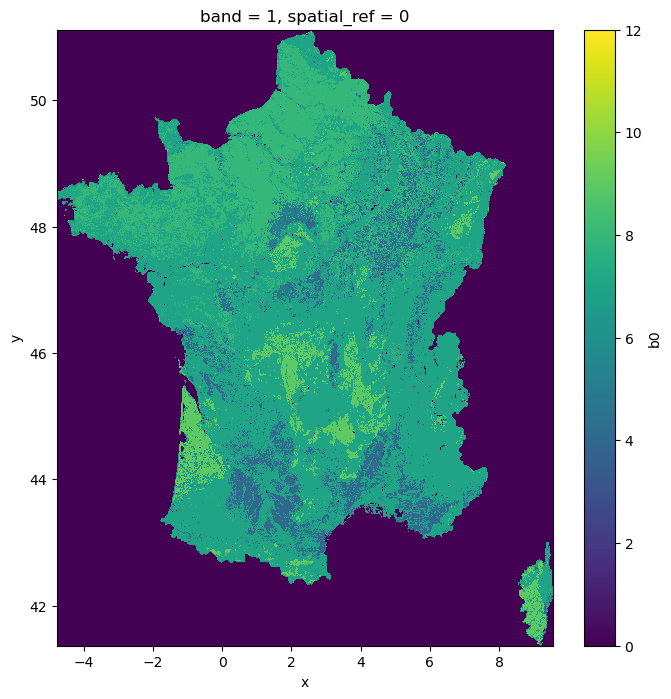

In [9]:
soil_text = rxr.open_rasterio(
    "/Users/mdmustafizurrahmanmunna/Desktop/Geospatial/France_Soil_Texture_b0.tif",
    masked=True
)

soil_text.plot(figsize=(8,8))
plt.show()

### Reproject the raster

In [10]:
soil_text = soil_text.rio.reproject(adm0.crs)
print(soil_text.rio.crs)
print(adm0.crs)

EPSG:4326
EPSG:4326


### Clip the raster

In [11]:
soil_text_c = soil_text.rio.clip(
    adm0.geometry,
    adm0.crs,
    drop=True
)

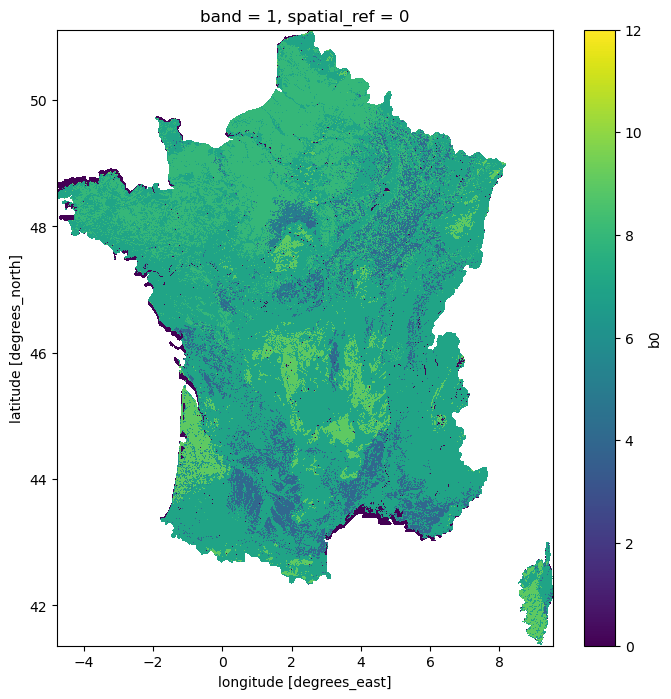

In [12]:
soil_text_c.plot(figsize=(8,8))
plt.show()

### Create the soil texture lookup table

In [13]:
soil_texture_lookup = pd.DataFrame({
    "b0": [
        1, 2, 3, 4, 5, 6,
        7, 8, 9, 10, 11, 12
    ],

    "description": [
        "Clay",
        "Silty Clay",
        "Sandy Clay",
        "Clay Loam",
        "Silty Clay Loam",
        "Sandy Clay Loam",
        "Loam",
        "Silty Loam",
        "Sandy Loam",
        "Silt",
        "Loamy Sand",
        "Sand"
    ],

    "color": [
        "#6E2D01",  # Clay
        "#CBE8F0",  # Silty Clay
        "#FEDB7B",  # Sandy Clay (closest available color)
        "#964B11",  # Clay Loam
        "#7599CE",  # Silty Clay Loam
        "#FEDB7B",  # Sandy Clay Loam
        "#CB610A",  # Loam
        "#DCDCDC",  # Silty Loam
        "#E0E27D",  # Sandy Loam
        "#BFD586",  # Silt
        "#EB7611",  # Loamy Sand
        "#F7A424"   # Sand
    ]
})

In [14]:
soil_df = (
    soil_text_c
    .to_dataframe(name="b0")
    .reset_index()
)

### Remove invalid values

In [16]:
soil_df = soil_df[soil_df["b0"] != 0]

In [17]:
soil_data = soil_df.merge(
    soil_texture_lookup,
    on="b0",
    how="left"
)

### Show the map

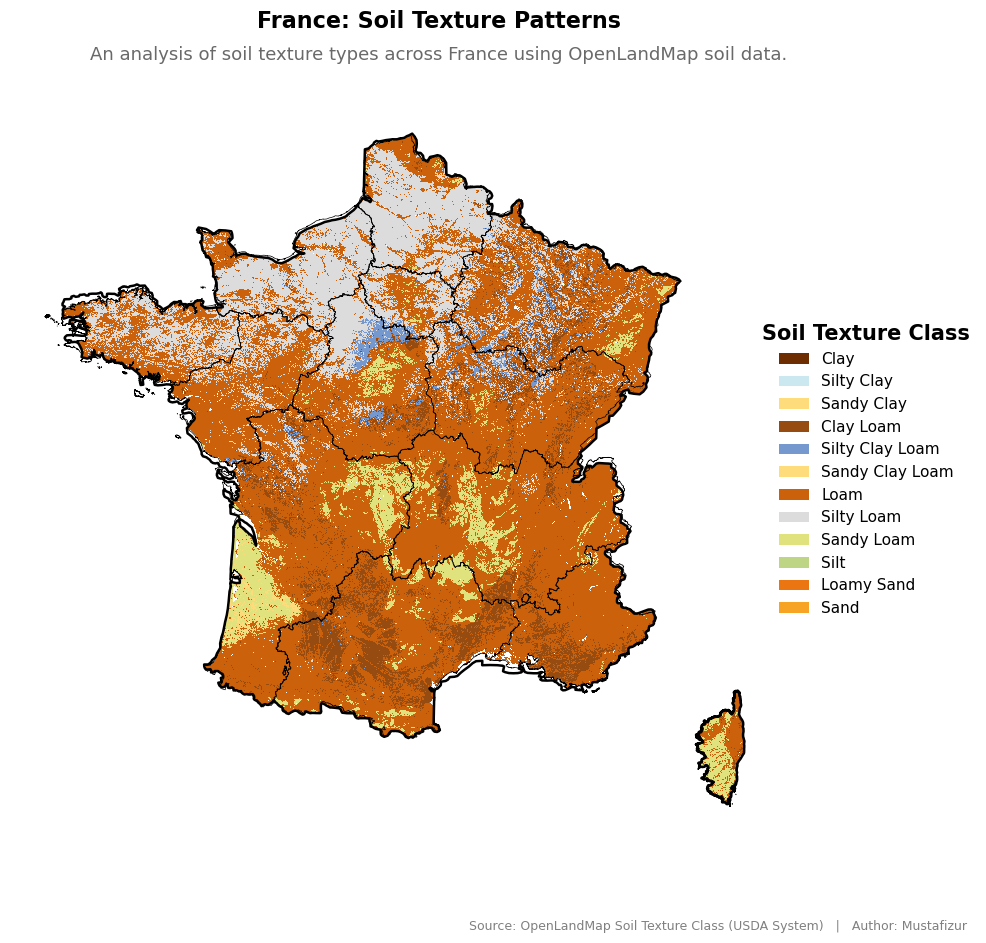

In [50]:
soil_classes = soil_texture_lookup["description"].tolist()
soil_colors = soil_texture_lookup["color"].tolist()

color_dict = dict(zip(soil_classes, soil_colors))

# Assign an integer to every soil class
class_to_int = {
    c: i
    for i, c in enumerate(soil_classes)
}
soil_data["class_id"] = soil_data["description"].map(class_to_int)

# Convert dataframe to raster grid
pivot = soil_data.pivot(
    index="y",
    columns="x",
    values="class_id"
)
pivot = pivot.sort_index(ascending=False)

grid = pivot.values

cmap = ListedColormap(soil_colors)

# Figure
fig = plt.figure(
    figsize=(11, 10),       
    facecolor="white"
)

# Bigger map area and lifted upward
ax = fig.add_axes(
    [0.05, 0.12, 0.82, 0.74]         # <<< EDIT
)

# Raster extent
extent = [
    soil_data["x"].min(),
    soil_data["x"].max(),
    soil_data["y"].min(),
    soil_data["y"].max()
]

# Raster
ax.imshow(
    grid,
    cmap=cmap,
    interpolation="nearest",
    extent=extent,
    aspect="equal"               
)

# Administrative boundaries
adm1.boundary.plot(
    ax=ax,
    color="black",
    linewidth=0.5
)

adm0.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1.8
)

# Remove axes
ax.axis("off")

# Titles
fig.suptitle(
    "France: Soil Texture Patterns",
    fontsize=16,
    fontweight="bold",
    y= 0.95
)

fig.text(
    0.5,
    0.90,                  
    "An analysis of soil texture types across France using OpenLandMap soil data.",
    ha="center",
    fontsize=13,
    color="dimgray"
)

# Legend
legend_handles = [
    Patch(
        facecolor=color_dict[name],
        edgecolor="none",
        linewidth=0,
        label=name
    )
    for name in soil_classes
]

legend = ax.legend(
    handles=legend_handles,
    title="Soil Texture Class",
    title_fontsize=15,               # <<< EDIT
    fontsize=11,                     # <<< EDIT
    loc="center left",
    bbox_to_anchor=(0.96, 0.5),
    frameon=False
)

legend.get_title().set_weight("bold")

# Footer
fig.text(
    0.98,
    0.03,
    "Source: OpenLandMap Soil Texture Class (USDA System)   |   Author: Mustafizur",
    ha="right",
    fontsize=9,
    color="gray"
)

# Save
fig.savefig(
    "France_Soil_Texture.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches= .40,          
    facecolor="white"
)

plt.show()